# Density method - $\nu$ interpolation - nonlinear magnetic model

In [1]:
from ngsolve import *
from ngsolve.webgui import Draw
import numpy as np
import matplotlib.pyplot as plt

## 1) Geometry

In [2]:
import os, sys
sys.path.append(os.path.relpath("core"))
from Geometry import transformer

mesh = transformer(NCoils = 2, hmax=0.005)

Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## 2) Magnetic behavior

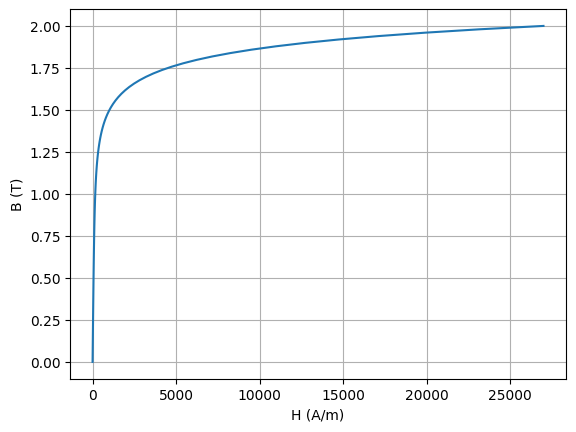

In [3]:
linear = False

nu0 = 1/(4e-7 * pi)

if linear:
    nu_iron = lambda b2 : nu0/1000
    dnu_iron_db2 = lambda b2 : 0
else:
    nu_iron = lambda b2 : 100 + 10 * exp(1.8 * b2) # from OneLab electrical machine template (https://gitlab.onelab.info/doc/models/-/blob/master/ElectricMachines/BH.pro)
    dnu_iron_db2 = lambda b2 :  18 * exp(1.8 * b2) 
    

B = np.linspace(0,2,100)
H = nu_iron(B**2) * B
plt.plot(H,B); plt.xlabel("H (A/m)"); plt.ylabel("B (T)"); plt.grid()
plt.show()

## 3) Interpolation of materials

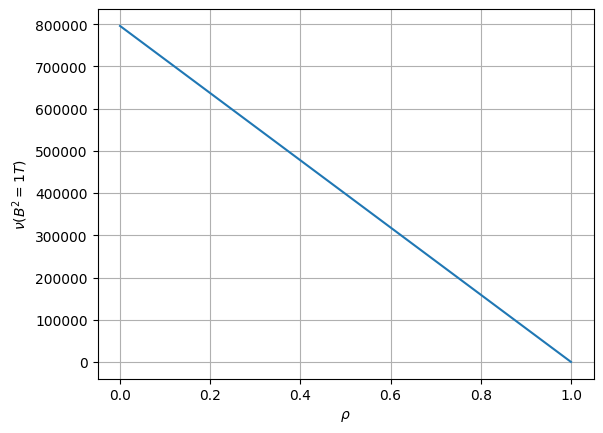

In [4]:
sys.path.append(os.path.relpath("utils"))
from Density import Interpolation

p = 1
I = Interpolation("power_law")
I.parameters["p"] = p

nu_interp = lambda b2, rho : nu0 + (nu_iron(b2) - nu0) * I(rho)
dnu_interp_db2 =  lambda b2, rho : dnu_iron_db2(b2) * I(rho)
dnu_interp_drho = lambda b2, rho : (nu_iron(b2) - nu0) * I.derivative(rho)

rhoTest = np.linspace(0,1,100)
plt.plot(rhoTest,nu_interp(1,rhoTest))
plt.xlabel("$\\rho$"); plt.ylabel("$\\nu(B^2=1T)$"); plt.grid()
plt.show()

## 4) Magnetostatics

In [5]:
FEM_order = 1 # try also with FEM_order > 1 (little bit longer computation then)
fes = H1(mesh, order = FEM_order, dirichlet = "out")

# Recall quadrature rule order in non-linear elements to ensure Newton convergence when order > 1
from ngsolve.comp import IntegrationRuleSpace
intrules = IntegrationRuleSpace(fes.mesh, order = fes.globalorder - 1).GetIntegrationRules()

rho = GridFunction(L2(mesh, definedon  = "Omega_c"))
rho.Set(1)

Curl = lambda u: grad(u)

def residual(u, v, rho = rho):
        jz = 10e6
        b0 = Curl(u)
        res = Curl(v) * nu0 * b0 * dx("Pp|Pm|Sp|Sm")
        res += Curl(v) * nu_interp(b0**2, rho) * b0 * dx("Omega_c", intrules = intrules)
        res +=  v * jz * dx("Pm") - v * jz * dx("Pp")
        return res.Compile()

-------------------- START NEWTON ---------------------
Initializing  ..... done (95.70 ms).
Initial residual : 1.22953e+03
Start loop  ....... 
 It 1 -------------------------------------------------
 - Assembly ....... done (184.21 ms).
 - Solve .......... done (125.06 ms).
 - Line search .... 
   it 0 : ||residual|| = nan | step =  1.00e+00
   it 1 : ||residual|| = nan | step =  5.00e-01
   it 2 : ||residual|| = nan | step =  2.50e-01
   it 3 : ||residual|| = nan | step =  1.25e-01
   it 4 : ||residual|| = nan | step =  6.25e-02
   it 5 : ||residual|| = inf | step =  3.12e-02
   it 6 : ||residual|| = 1.11151e+72 | step =  1.56e-02
   it 7 : ||residual|| = 2.43308e+17 | step =  7.81e-03
   it 8 : ||residual|| = 4.57484e+03 | step =  3.91e-03
   it 9 : ||residual|| = 1.22689e+03 | step =  1.95e-03
 - Line search done (772.98 ms).
 - Conv : ||residual|| = 1.22689e+03 | decr = 2.42763e+02
 - Newton iteration done (1204.56 ms).
 It 2 -------------------------------------------------
 - A

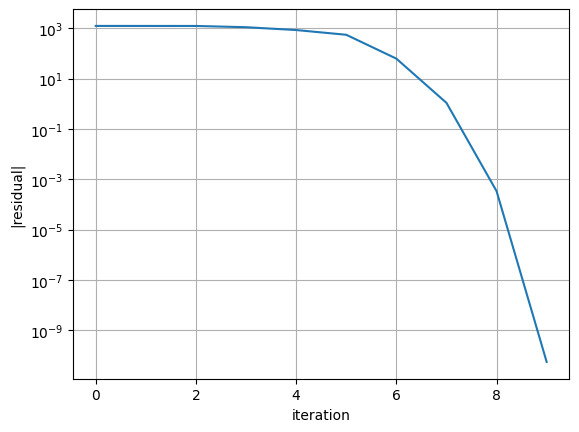

In [6]:
from Solver import solve

state = solve(fes, residual, verbosity=3)
plt.semilogy(state["residual"])
plt.grid(); plt.ylabel("|residual|"); plt.xlabel("iteration")
plt.show()

## 5) Objective function & adjoint problem
### a) Objective function

In [7]:
def avgSecondaryFlux(state):
    return Integrate ( state, mesh.Materials("Sp") ) - Integrate ( state, mesh.Materials("Sm") ) 


# we want to maximize the secondary flux = minimize its opposite

normalization = 1e-3    # so that the objective function is comparable to the constraint

def objectiveFunction(state):
    return - avgSecondaryFlux(state) / normalization

print(f" {objectiveFunction(state["solution"]) = :.5e} Wb/m")

 objectiveFunction(state["solution"]) = -1.58853e-03 Wb/m


### b) Adjoint problem

In [8]:
def objectiveFunctionDD(a, aStar):
    """ Directional derivative of the objective function in the direction aStar """
    return aStar/ normalization *dx("Sm")  - aStar/ normalization*dx("Sp")

from Solver import solveAdjoint

adjoint = solveAdjoint(state["solution"], state["last_inverse"], objectiveFunctionDD)

Draw(adjoint, mesh, settings = {"Objects" : { "Wireframe" : False } })

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

## 6) Gradient of objective function w.r.t $\rho$

In [9]:
def dobjectiveFunction_drho(rho, state, adjoint):
    b= Curl(state)
    return - Curl(adjoint) * (dnu_interp_drho(b**2, rho) * b)

Draw(dobjectiveFunction_drho(rho, state["solution"], adjoint), mesh, settings = {"Objects" : { "Wireframe" : False } })

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

## 6) Volume

In [10]:
V0 = Integrate(CF((1)), mesh) # volume of Omega

def volume(rho):
    return Integrate(rho, mesh) / V0

def dvolume_drho(rho):
    """ Scalar field representing the linear form obtained by the directional derivative of the volume 
    The directionnal derivative in the gamma direction reads < dvolume_drho, gamma > """
    return CF((1)) / V0

## 7) Optimization

We use an augmented Lagrange algorithm. We want to find the saddle point of the augmented Lagrangian

$$ \mathcal L(\rho,\lambda) = f(\rho) + \lambda g(\rho) + \frac{\beta}{2} (g(\rho))^2$$

with $f$ the objective function, $\lambda$ a Lagrange multiplier and $g$ an equality constraint. So, $\mathcal L$ should be minimized w.r.t $\rho$ and maximized w.r.t $\lambda$ :

$$ (\rho^*, \lambda^*) = \arg \max_\lambda \min_{\rho} L(\rho,\lambda)  $$

The algorithm is the following loop :
- Inner minimization of $\mathcal L(\rho,\lambda)$ w.r.t $\rho$
- Update of $\lambda$ such that $\lambda \gets \lambda + \beta g(\rho)$ so that $\lambda$ increases

### a) Inner minimization

We use a projected gradient descent with simple step control.

In [11]:
from copy import copy

mask = GridFunction(L2(mesh))
mask.Set(mesh.MaterialCF({"Omega_c" : 1}))
maskOmega_c = mask.vec.FV().NumPy()[:]

def innerMinimization(rho, lam, 
                      step = 0.1, beta = 1e-3,
                      n_max = 50, step_min = 1e-4, 
                      f = objectiveFunction,                                # df_du(u)
                      g = lambda rho : (volume(rho) - 0.1),                 # g(rho)
                      df_du = objectiveFunctionDD,                          # df_du(u, uStar)
                      dg_drho = dvolume_drho,                               # dg_drho(rho)
                      df_drho = dobjectiveFunction_drho,                    # df_drho(rho, u, p)
                      maskOmega_c = maskOmega_c,                            # mask of the optimization domain
                      scene = None):
    n = 0
    Lagr = lambda rho, u : f(u) + lam * g(rho) + beta / 2 * (g(rho))**2
    dLagr_drho = lambda rho, u, p : df_drho(rho, u, p) + lam * dg_drho(rho) + beta * g(rho)

    state = solve(fes, lambda u, v: residual(u, v, rho=rho))
    L_history = [Lagr( rho, state["solution"])]
    obj_history = [f(state["solution"])]
    g_history = [g(rho)]
    rho_history = [copy(rho)]
    while ( n < n_max and step > step_min):

        n += 1
        if scene is not None : scene.Redraw(rho, min=0, max=1, settings = {"Objects" : { "Wireframe" : False } })
    
        # 1) Magnetic state computation
        state = solve(fes, lambda u, v: residual(u, v, rho=rho), initial_guess=state["solution"])
        
        # 2) Adjoint computation
        adjoint = solveAdjoint(state["solution"], state["last_inverse"], df_du)
        
        # 3) Gradient computation
        gradient = dLagr_drho(rho, state["solution"], adjoint)

        # 4) Update
        rho_test = GridFunction(rho.space)
        rho_test.Set(rho - step * gradient)
        
        # 5) Projection
        rho_test.vec[:].FV().NumPy()[rho_test.vec[:].FV().NumPy()<0] = 0
        rho_test.vec[:].FV().NumPy()[rho_test.vec[:].FV().NumPy()>1] = 1
        rho_test.vec[:].FV().NumPy()[maskOmega_c==0] = 0
        
        # 6) Step control
        state_test = solve(fes, lambda u, v: residual(u, v, rho=rho_test), initial_guess=state["solution"])
        L_history.append(Lagr(rho_test, state_test["solution"]))
        g_history.append(g(rho_test))
        obj_history.append(f(state_test["solution"]))
        
        print(f'it n°{n} | f = {L_history[-1] :.6e} | g = {g_history[-1]  :.3e} | {step = : .3e}                   ')
        
        if L_history[-1] >= L_history[-2]:   # failure
            step *= 0.5
            L_history.pop(); g_history.pop() ; obj_history.pop()
        else :                               # succes
            step *= 1.2
            rho = rho_test
            rho_history.append(copy(rho))
    return rho_history, L_history, obj_history, g_history, step, n 

### b) Optimization parameters

In [12]:
## Initialization
mass_target = 0.1   # Target volume
rho0 = mass_target; # Initial value of rho (homogeneous)
rho = GridFunction(L2(mesh))
rho.Set(mesh.MaterialCF({ "Omega_c" : rho0}, default=0))

beta = 0.01         # Penalization coefficient
lam = 0              # Initial value of Lagrange multiplier

step = 10          # Initial step
step_min = 1e-4     # Minimal step 
N_outer_max = 10     # Maximal number of outer iteration (maximization)
N_inner_max = 10     # Maximal number of inner iteration (minimization)

N_outer = 0
N_endInner = [0]
N_iter_tot = 0
Lagr_OuterList, g_OuterList, f_OuterList = [], [], []
lamList = [lam]
rho_OuterList = [rho]
stepList = [step]

### c) Optimization loop

In [13]:
scene = Draw(rho, min=0, max=1, settings = {"Objects" : { "Wireframe" : False } })

g  = lambda rho : (volume(rho) - 0.1)

for N_outer in range(N_outer_max) :

    print(f"\n{N_outer = }")

    rho_history, L_history, obj_history, g_history, step, N_inner = innerMinimization(rho, lam,
                                                           step = step, 
                                                           beta = beta,
                                                           g = g,
                                                           n_max = N_inner_max, 
                                                           step_min = step_min, 
                                                           scene = scene)
    
    rho = rho_history[-1]
    rho_OuterList.append(copy(rho))
    Lagr_OuterList.append(L_history[-1])
    g_OuterList.append(g_history[-1])
    f_OuterList.append(obj_history[-1])
    N_iter_tot += N_inner
    N_endInner.append(N_iter_tot)
    stepList.append(step)
    step *= 2
    # update Lagrange multiplier
    lam += beta * g(rho)
    lamList.append(lam)
    
    

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…


N_outer = 0
it n°1 | f = -4.983884e-05 | g = 7.876e-04 | step =  1.000e+01                   
it n°2 | f = -6.381880e-05 | g = 2.941e-03 | step =  1.200e+01                   
it n°3 | f = -1.563152e-04 | g = 7.440e-03 | step =  1.440e+01                   
it n°4 | f = -5.386297e-04 | g = 1.847e-02 | step =  1.728e+01                   
it n°5 | f = -1.456682e-02 | g = 4.797e-02 | step =  2.074e+01                   
it n°6 | f = -2.697235e-02 | g = 2.433e-02 | step =  2.488e+01                   
it n°7 | f = -3.081390e-02 | g = 2.987e-02 | step =  2.986e+01                   
it n°8 | f = -3.136328e-02 | g = 1.809e-02 | step =  3.583e+01                   
it n°9 | f = -3.142842e-02 | g = 7.743e-03 | step =  4.300e+01                   
it n°10 | f = -3.144044e-02 | g = 5.190e-04 | step =  5.160e+01                   

N_outer = 1
it n°1 | f = -3.146180e-02 | g = -8.852e-03 | step =  1.238e+02                   
it n°2 | f = -3.146522e-02 | g = -1.023e-02 | step =  1.486e+02       

## 8) Analysis of the results

### a) Quantities of interest

In [14]:
state = solve(fes, lambda u, v: residual(u, v, rho=rho))
print(f"Results Density (mu) : flux = {avgSecondaryFlux(state["solution"]) : .5e} | vol = {volume(rho)*100 : .3f} % | iterations = {N_iter_tot}")

Results Density (mu) : flux =  3.14722e-05 | vol =  9.820 % | iterations = 100


### b) Evolution of the objective function and constraint

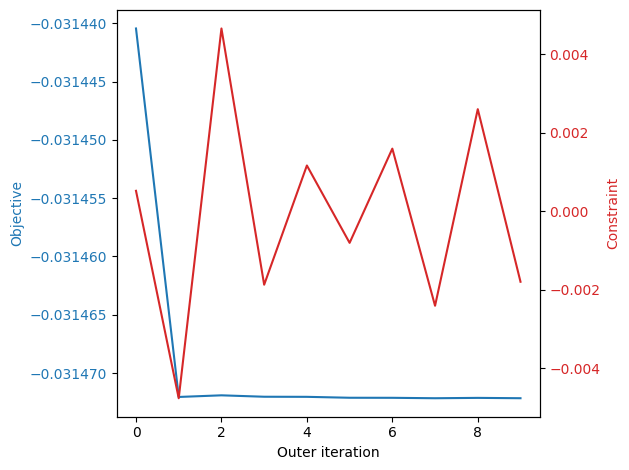

In [15]:
fig, ax1 = plt.subplots(); color = 'tab:blue'
ax1.plot(f_OuterList, color = color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('Outer iteration'); ax1.set_ylabel("Objective", color = color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Constraint", color=color)
ax2.plot(g_OuterList, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.show()

### b) Evolution of lambda and step

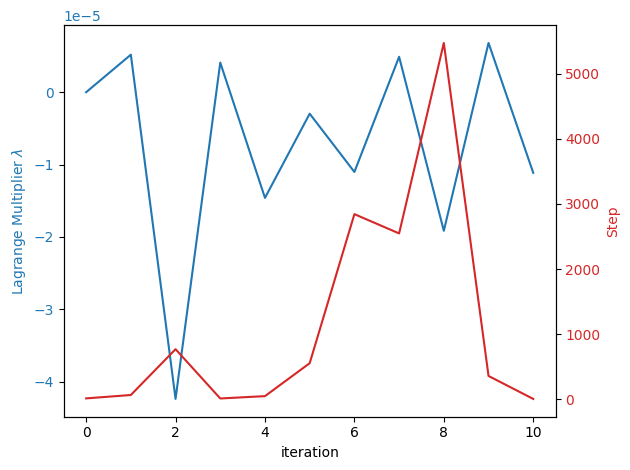

In [16]:
fig, ax1 = plt.subplots(); color = 'tab:blue'
ax1.plot(lamList, color = color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('iteration'); ax1.set_ylabel("Lagrange Multiplier $\lambda$", color = color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Step", color=color)
ax2.plot(stepList, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.show()